In [81]:
import numpy as np
from struct import unpack
import matplotlib.pyplot as plt

In [94]:
marker_mapping = {
    0xffd8: "Start of Image",
    0xffe0: "Application Default Header",
    0xffdb: "Quantization Table",
    0xffc0: "Start of Frame",
    0xffc4: "Define Huffman Table",
    0xffda: "Start of Scan",
    0xffd9: "End of Image"
}

def GetArray(type, l, length):
    s = ""
    for i in range(length):
        s = s + type
    return list(unpack(s, l[:length]))

def RemoveFF00(data):
    datapro = []
    i = 0
    while True:
        b, bnext = unpack("BB", data[i:i+2])
        if b == 0xFF:
            if bnext !=0:
                break
            datapro.append(data[i])
            i+=2
        else:
            datapro.append(data[i])
            i += 1
    return datapro, i

def DecodeNumber(code, bits):
    l = 2 ** (code -1)
    if bits >= l:
        return bits
    else:
        return bits - (2 * l -1)

def Clamp(col):
    """
    Makes sure col is between 0 and 255.
    """
    col = 255 if col > 255 else col
    col = 0 if col < 0 else col
    return int(col)

def ColorConversion(Y, Cb, Cr):
    R = np.zeros_like(Y.base)
    G = np.zeros_like(Y.base)
    B = np.zeros_like(Y.base)
    for i in range(8):
        for j in range(8):
            R[i,j] = Y.base[i][j] + (Cr.base[i][j] - 128) * 1.402 
            G[i,j] = Y.base[i][j] - (Cb.base[i][j] - 128)*0.34414 - (Cr.base[i][j] - 128)*0.71414
            B[i,j] = Y.base[i][j] + (Cb.base[i][j]- 128) * 1.772 
            # R[i,j] = Clamp((Cr.base[i][j] * (2 - 2 * 0.299) + Y.base[i][j]))
            # B[i,j] = Clamp((Cb.base[i][j] * (2 - 2 * 0.114) + Y.base[i][j]))
            # G[i,j] = Clamp(((Y.base[i][j] - 0.114 * B[i,j] - 0.299 * R[i,j]) / 0.587))
    return R, G, B


In [83]:
class Stream:
    def __init__(self, data):
        self.data = data
        self.pos = 0

    def GetBit(self):
        b = self.data[self.pos >> 3]
        s = 7 - (self.pos & 0x7)
        self.pos += 1
        return (b >> s) & 1
    
    def GetBitN(self, l):
        val = 0
        for _ in range(l):
            val = val *2 + self.GetBit()
        return val
    
    def len(self):
        return len(self.data)
    

In [84]:
class HuffmanTable:
    def __init__(self):
        self.root = []
        self.elements = []

    def BitsFromLengths(self, root, element, pos):
        if isinstance(root, list):
            if pos == 0:
                if len(root) < 2:
                    root.append(element)
                    return True
                return False
            for i in [0, 1]:
                if len(root) == i:
                    root.append([])
                if self.BitsFromLengths(root[i], element, pos-1)== True:
                    return True
        return False

    def GetHuffmanBits(self, lengths, elements):
        self.elements = elements
        ii = 0
        for i in range(len(lengths)):
            for j in range(lengths[i]):
                self.BitsFromLengths(self.root, elements[ii], i)
                ii += 1

    def Find(self, st):
        r = self.root
        while isinstance(r, list):
            r = r[st.GetBit()]
        return r

    def GetCode(self, st):
        while True:
            res = self.Find(st)
            if res == 0:
                return 0
            elif res != -1:
                return res


In [85]:
class IDCT:
    def __init__(self):
        self.base = [0] *64
        self.zigzag = [
            [0, 1, 5, 6, 14, 15, 27, 28],
            [2, 4, 7, 13, 16, 26, 29, 42],
            [3, 8, 12, 17, 25, 30, 41, 43],
            [9, 11, 18, 24, 31, 40, 44, 53],
            [10, 19, 23, 32, 39, 45, 52, 54],
            [20, 22, 33, 38, 46, 51, 55, 60],
            [21, 34, 37, 47, 50, 56, 59, 61],
            [35, 36, 48, 49, 57, 58, 62, 63],
        ]
        self.idct_precision = 8
        self.idct_table = [
            [
                (self.NormCoeff(u)*np.cos(((2*x+1) * u * np.pi)/16))
                for x in range(self.idct_precision)
            ]
            for u in range(self.idct_precision)
        ]
    
    def NormCoeff(self, n):
        if n == 0:
            return 1/np.sqrt(2)
        else:
            return 1
        
    def rearrange_using_zigzag(self):
        for x in range(8):
            for y in range(8):
                self.zigzag[x][y] = self.base[self.zigzag[x][y]]

    def perform_IDCT(self):
        out = [list(range(8)) for i in range(8)]

        for x in range(8):
            for y in range(8):
                local_sum = 0
                for u in range(self.idct_precision):
                    for v in range(self.idct_precision):
                        local_sum += (self.zigzag[v][u] * self.idct_table[u][x] * self.idct_table[v][y])
                out[y][x] = local_sum // 4
        self.base = out

Start of Image
Application Default Header
Quantization Table
Quantization Table
Start of Frame
Define Huffman Table
0 0 0
[0, 1, 4, 3, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0]
[7, 5, 6, 8, 9, 3, 4, 10, 2, 1, 0, 11]
Define Huffman Table
16 0 1
[0, 3, 1, 0, 1, 4, 2, 2, 2, 2, 1, 4, 1, 2, 0, 15]
[1, 2, 3, 4, 5, 6, 17, 18, 19, 7, 20, 8, 34, 33, 35, 0, 9, 21, 36, 49, 50, 51, 22, 23, 65, 66, 10, 37, 52, 67, 39, 24, 38, 40, 53, 68, 81, 82, 83, 114]
Define Huffman Table
1 1 0
[0, 1, 4, 3, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[5, 3, 4, 6, 7, 1, 2, 8, 9, 0, 10]
Define Huffman Table
17 1 1
[0, 3, 0, 2, 2, 1, 3, 3, 4, 1, 4, 1, 4, 1, 0, 11]
[1, 2, 3, 4, 18, 17, 19, 5, 6, 33, 34, 7, 20, 35, 0, 8, 49, 50, 21, 36, 51, 65, 66, 81, 22, 23, 67, 82, 52, 9, 37, 97, 24, 38, 83, 98, 113, 53, 114, 129]
Start of Scan
End of Image


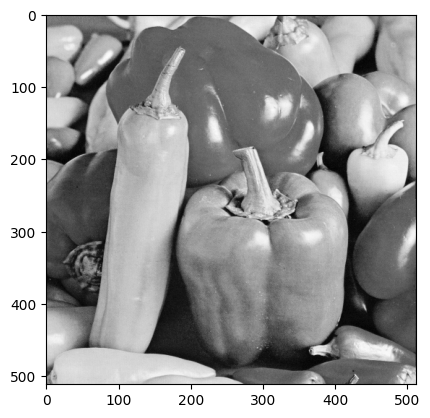

In [100]:
class JPEG:
    def __init__(self, image_file):
        self.huffman_tables = {}
        self.quant = {}
        self.quantMapping = []
        with open(image_file, 'rb') as f:
            self.img_data = f.read()
    
    def DefineQuantizationTables(self, data):
        hdr, = unpack("B", data[0:1])
        self.quant[hdr] = GetArray("B", data[1:1+64], 64)
        data = data[65:]

    def BuildMatrix(self, st, idx, quant, olddccoef):
        i = IDCT()
        code = self.huffman_tables[0+idx].GetCode(st)
        bits = st.GetBitN(code)
        dccoef = DecodeNumber(code, bits) + olddccoef

        i.base[0] = (dccoef) * quant[0]
        l = 1
        while l < 64:
            code = self.huffman_tables[16 + idx].GetCode(st)
            if code == 0:
                break

            if code > 15:
                l += code >> 4
                code = code & 0x0F
            bits = st.GetBitN(code)
            if l < 64:
                coeff = DecodeNumber(code, bits)
                i.base[l] = coeff * quant[l]
                l += 1
        i.rearrange_using_zigzag()
        i.perform_IDCT()
        return i, dccoef

    def decodeHuffman(self, data):
        offset = 0
        header, = unpack("B", data[offset:offset+1])
        print(header, header & 0x0F, (header >> 4) & 0x0F)
        offset +=1
        lengths = GetArray("B", data[offset:offset+16], 16)
        offset += 16
        elements = []
        for i in lengths:
            elements += GetArray("B", data[offset:offset+i],i)
            offset += i
        hf = HuffmanTable()
        print(lengths)
        print(elements)
        hf.GetHuffmanBits(lengths, elements)
        self.huffman_tables[header] = hf
        data = data[offset:]

    def StartOfScan(self, data, hdrlen):
        self.image = np.zeros((self.height, self.width, 3))
        data, lenchunk = RemoveFF00(data[hdrlen:])
        st = Stream(data)
        oldlumdc, oldcbdc, oldcrdc = 0, 0, 0
        for y in range(self.height // 8):
            for x in range(self.width // 8):
                matL, oldlumdc = self.BuildMatrix(st, 0, self.quant[self.quantMapping[0]], oldlumdc)
                matCb, oldcbdc = self.BuildMatrix(st, 1, self.quant[self.quantMapping[1]], oldcbdc)
                matCr, oldcrdc = self.BuildMatrix(st, 1, self.quant[self.quantMapping[2]], oldcrdc)
                R, G, B = ColorConversion(matL, matCb, matCr)
                self.image[y*8:y*8+8,x*8:x*8+8,0] = matL.base
                self.image[y*8:y*8+8,x*8:x*8+8,1] = matCb.base
                self.image[y*8:y*8+8,x*8:x*8+8,2] = B
        return lenchunk+hdrlen
    def BaselineDCT(self, data):
        hdr, self.height, self.width, components = unpack(">BHHB", data[0:6])
        for i in range(components):
            id, samp, QtbId = unpack("BBB", data[6 + i*3:9+i*3])
            self.quantMapping.append(QtbId)

    def decode(self):
        data = self.img_data
        while(True):
            marker, = unpack(">H", data[0:2])
            print(marker_mapping.get(marker))
            if marker == 0xffd8:
                data = data[2:]
            elif marker == 0xffd9:
                return
            else:
                lenchunk, = unpack(">H", data[2:4])
                lenchunk += 2
                chunk = data[4:lenchunk]
                if marker == 0xffc4:
                    self.decodeHuffman(chunk)
                elif marker == 0xffdb:
                    self.DefineQuantizationTables(chunk)
                elif marker == 0xffc0:
                    self.BaselineDCT(chunk)
                elif marker == 0xffda:
                    lenchunk = self.StartOfScan(data, lenchunk)
                
                data = data[lenchunk:]  

            if len(data)==0:
                break        

if __name__ == "__main__":
    img = JPEG('peppers.jpg')
    img.decode() 
    plt.imshow(img.image[:,:,0], cmap="gray")